# Feature Engineering & Hyperparameter Tuning

<hr style="height: 5px; background-color: #5A98C4 ; border: none;">

### Learning Objectives From This Notebook
- Engineer new features and apply appropriate transformations.
- Distinguish hyperparameters from learned parameters.
- Tune a model systematically with GridSearchCV and cross-validation.

### Table of Contents:

1. [Section 1 — Feature Engineering](#section1)
2. [Section 2 — Common Techniques in Feature Engineering](#section2)
3. [Section 3 — Hyperparameters vs. Parameters](#section3)
4. [Section 4 — Hyperparameter Tuning with Scikit-Learn](#section4)
5. [Section 5 — Hands-on Lap](#section5)
6. [References](#refs)

<hr style="height: 5px; background-color: #5A98C4 ; border: none;">

<a id="section1"></a>
# Section 1 : Feature Engineering

## 1.1 What Is Feature Engineering?


> **Feature Engineering** is the process of selecting, creating or modifying features like input variables or data to help machine learning models learn patterns more effectively. It involves transforming raw data into meaningful inputs that improve model accuracy and performance.
>**This step may include handling missing values, encoding categories, scaling numbers, creating new features or combining existing ones**. It helps turn messy real-world data into a form that models can understand and use for better predictions.



>  <div style="text-align: center;"> <img src="pipeline.png" alt="Feature ngineering in ML pipeline " width="600" > </div>

#### Importance of Feature Engineering
- **Improve accuracy:** Choosing the right features helps the model learn better, leading to more accurate predictions.
- **Reduce overfitting:** Using fewer, more important features helps the model avoid memorizing the data and perform better on new data.
- **Boost interpretability:** Well-chosen features make it easier to understand how the model makes its predictions.
- **Enhance efficiency:** Focusing on key features speeds up the model’s training and prediction process, saving time and resources.

#### Steps in Feature Engineering
> Feature engineering can vary depending on the specific problem but the general steps are:

1. **Data Cleaning:** Identify and correct errors or inconsistencies in the dataset to ensure data quality and reliability.
2. **Data Transformation:** Transform raw data into a format suitable for modeling including scaling, normalization and encoding.
3. **Feature Extraction:** Create new features by combining or deriving information from existing ones to provide more meaningful input to the model.
4. **Feature Selection:** Choose the most relevant features for the model using techniques like correlation analysis, mutual information and stepwise regression.
5. **Feature Iteration:** Continuously refine features based on model performance by adding, removing or modifying features for improvement.

<hr style="height: 5px; background-color: #5A98C4 ; border: none;">

<a id="section2"></a>
# Section 2 : Common Techniques in Feature Engineering

## 2.1   One-Hot Encoding

 Used to convert categorical data into a numerical format that machine learning models can understand. It creates separate binary columns for each category, where 1 represents the presence of a category and 0 represents its absence.

### 2.1.1 How One-Hot Encoding Works


One-Hot Encoding creates a separate column for each category in the dataset. In the fruit example, when the fruit is Apple, the `Fruit_Apple` column gets the value `1` while the other fruit columns contain `0`. Similarly, for Mango and Orange, their respective columns contain `1` and the remaining columns contain `0`.

- Each category gets its own binary column
- `1` indicates the presence of a category
- `0` indicates the absence of a category
- Converts categorical values into numerical format for machine learning models

#### Original Data

| Fruit  | Categorical value of fruit | Price |
|--------|---------------------------|-------|
| apple  | 1                         | 5     |
| mango  | 2                         | 10    |
| apple  | 1                         | 15    |
| orange | 3                         | 20    |

#### The output after applying One-Hot Encoding



| Fruit_apple | Fruit_mango | Fruit_orange | Price |
|-------------|-------------|--------------|-------|
| 1           | 0           | 0            | 5     |
| 0           | 1           | 0            | 10    |
| 1           | 0           | 0            | 15    |
| 0           | 0           | 1            | 20    |

### 2.1.2 Implementation



One-Hot Encoding can be implemented in Python using libraries such as Pandas and Scikit-learn, which provide simple and efficient methods for converting categorical data into binary columns.



#### 1. Using Pandas



Pandas provides the `get_dummies()` function to perform one-hot encoding on categorical columns.

- Converts categorical values into binary columns
- Easy and efficient for preprocessing datasets
- `drop_first=True` removes one redundant column to avoid multicollinearity
- Example: Gender with values M and F becomes `Gender_M` and `Gender_F` columns

```python
import pandas as pd

data = {
    'Employee_ID': [10, 20, 15, 25, 30],
    'Gender': ['M', 'F', 'F', 'M', 'F'],
    'Remarks': ['Good', 'Nice', 'Good', 'Great', 'Nice']
}

df = pd.DataFrame(data)

print("Original Data:")
print(df)

encoded_df = pd.get_dummies(
    df,
    columns=['Gender', 'Remarks'],
    drop_first=True
)

print("\nOne-Hot Encoded Data:")
print(encoded_df)
```

#### 2. Using Scikit Learn Library

Scikit-learn (sklearn) provides the `OneHotEncoder` function to convert categorical variables into binary columns for machine learning models.

- Converts categorical data into binary format
- Automatically identifies categories
- Useful for machine learning preprocessing
- `select_dtypes()` helps select categorical columns automatically

```python
import pandas as pd
from sklearn.preprocessing import OneHotEncoder

data = {
    'Employee_ID': [10, 20, 15, 25, 30],
    'Gender': ['M', 'F', 'F', 'M', 'F'],
    'Remarks': ['Good', 'Nice', 'Good', 'Great', 'Nice']
}

df = pd.DataFrame(data)

print("Original Data:")
print(df)

categorical_columns = df.select_dtypes(include=['object']).columns

encoder = OneHotEncoder(sparse_output=False)

encoded_data = encoder.fit_transform(df[categorical_columns])

encoded_df = pd.DataFrame(
    encoded_data,
    columns=encoder.get_feature_names_out(categorical_columns)
)

final_df = pd.concat(
    [df.drop(columns=categorical_columns), encoded_df],
    axis=1
)

print("\nOne-Hot Encoded Data:")
print(final_df)
```

--------------

## 2.2   Binning (bucketing )

### 2.2.1 How Does it Work?
>**transforms continuous variables into discrete bins, making them categorical for easier analysis.**
>
more detailed explination :
>Data binning or bucketing is a data preprocessing method used to minimize the effects of small observation errors. The original data values are divided into small intervals known as bins and then they are replaced by a general value calculated for that bin. This has a smoothing effect on the input data and may also reduce the chances of overfitting in the case of small datasets



### 2.2.2 Why Binning is Important?
- **Data Smoothing:** Binning helps reduce the impact of minor observation variations, effectively smoothing the data.
- **Outlier Mitigation:** It reduces the influence of outliers by grouping values into bins.
- **Improved Analysis:** Discretizing continuous data simplifies data analysis and enables better visualization.
- **Feature Engineering:** Binned variables can be more intuitive and useful in predictive modeling.

### 2.2.3 Steps in Binning
1. **Sort the Data:** Arrange the values of the variable in ascending order.
2. **Define Bin Boundaries:** Based on the chosen binning method, determine the intervals.
3. **Assign Data Points to Bins:** Allocate each data point to its corresponding bin based on its value.

### 2.2.4 Implementation

#### 1. Custom / Manual Binning 

Use this method when you want to define specific, custom ranges based on domain knowledge (e.g., standard demographic age groups).

```python
import pandas as pd

# Sample Data
df = pd.DataFrame({'Age': [12, 22, 25, 38, 45, 61, 75]})

# Syntax: define edges (N+1 edges for N bins) and labels
bins = [0, 18, 35, 60, 100]
labels = ['Child', 'Young Adult', 'Middle Aged', 'Senior']

# Implementation
df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels, include_lowest=True)
print(df)

```

#### 2.  Equal-Width Binning

This automatically divides the entire range of the data into an exact number of groups with identical interval sizes.

```python
import pandas as pd

df = pd.DataFrame({'Income': [15000, 22000, 45000, 80000, 95000, 150000]})

# Syntax: pass an integer to the bins parameter instead of a list
df['Income_Group'] = pd.cut(df['Income'], bins=3, labels=['Low', 'Medium', 'High'])
print(df)
```

#### 3. Equal-Frequency / Quantile Binning

This divides data so that every single bin contains roughly the same number of data points. It is highly effective for skewed distributions

```python
import pandas as pd

df = pd.DataFrame({'Score': [1, 2, 2, 3, 4, 10, 20, 40, 100, 500]})

# Syntax: use qcut and specify the number of quantiles (e.g., 4 for quartiles)
df['Score_Rank'] = pd.qcut(df['Score'], q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'])
print(df)
```

#### 4. With scikit-learn

When building predictive models, you should use KBinsDiscretizer to prevent data leakage during cross-validation. This transformer learns the bin edges from your training data and applies them to your test data

```python
from sklearn.preprocessing import KBinsDiscretizer
import numpy as np

# Sample feature matrix (must be 2D)
X = np.array([[10], [20], [30], [40], [50], [60]])

# Syntax: options for strategy include 'uniform' (equal-width) or 'quantile' (equal-freq)
est = KBinsDiscretizer(n_bins=3, encode='ordinal', strategy='uniform')

# Fit to training data and transform
X_binned = est.fit_transform(X)
print(X_binned)

```

### 2.2.5 Summary Table of All Functions

| Method                                  | Technique        | Best Used For              |
| --------------------------------------- | ---------------- | -------------------------- |
| `pd.cut()` with custom edges            | Custom binning   | Domain-specific ranges     |
| `pd.cut()` with integer `bins`          | Equal-width      | Relatively uniform data    |
| `pd.qcut()`                             | Equal-frequency  | Skewed or clustered data   |
| `KBinsDiscretizer(strategy="uniform")`  | Equal-width      | ML pipelines               |
| `KBinsDiscretizer(strategy="quantile")` | Equal-frequency  | ML pipelines               |
| `KBinsDiscretizer(strategy="kmeans")`   | Clustering-based | Data with natural clusters |

-------

## 2.3   Creating Features

### What Is It
>  **Building entirely new features by combining or calculating from existing data, such as creating "age" from a birth date.**


**Example:**
```python
 df["total_cost"] = df["price"] + df["shipping"]

df["income_per_person"] = df["income"] / df["household_size"]

df["total_family"] = df["SibSp"] + df["Parch"] + 1
```

- **The goal** is to represent information that may be more meaningful or useful to the model than the original variables individually.
- **Important:** Feature creation should have a meaningful reason behind it. Creating many arbitrary columns does not automatically improve a model.

## 2.4   Feature Scaling

### 2.4.1 What is it?

> **Feature scaling transforms numerical features so that their values are on comparable scales.**
>
#### NOTE :
> this technique was used before in  [week3 day 3 notebook](https://github.com/thimarArda/BinX_AI_-_ML_Training/blob/main/Week3_Spervised_Learning/Day3_Logistic_Regression_and_Classification_Metrics/Day3_%20Logistic_Regression_and_Classification_Metrics.ipynb) when dealt with the `breast cancer dataset` while training logestic regression model due to the differences in the data ranges.  it can be implemented when dealing with datasets that have relativly larg numbers (like house price) to other numerical values like number of rooms.

### 2.4.2 Example : Suppose a dataset contains:

-  Age       → 18–80
- Income    → 1,000–100,000

> The features have very different numerical ranges.

**Scaling can be important for algorithms that are sensitive to feature magnitude, such as:**

- k-NN
- k-means
- SVM
- Logistic Regression
- Neural Networks

> Tree-based models such as Random Forest generally do not require feature scaling.

### 2.4.3 Implementaion


| Method           | Result                           |
| ---------------- | -------------------------------- |
| `StandardScaler` | Mean ≈ 0, standard deviation ≈ 1 |
| `MinMaxScaler`   | Values usually between 0 and 1   |

#### 1. Standardization

`StandardScaler` transforms a feature using:
$$z = \frac{x - \mu}{\sigma}$$

**where:**

- $x$ = original value
- $\mu$ = feature mean
- $\sigma$ = feature standard deviation

After standardization, the feature approximately has:
```output
mean = 0
standard deviation = 1
```

##### Syntax

```python
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
```

**Important: `fit` only on training data**
The scaler must learn its mean and standard deviation **only from the training data.** `scaler.fit(X_train)
`


#### 2. Min-Max Scaling

`MinMaxScaler` transforms values into a specified range, usually $[0,1]$.
```python
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
```

The general transformation is:
$$x' = \frac{x - x_{\min}}{x_{\max} - x_{\min}}$$

--------------


## 2.5   Datetime extraction

### 2.5.1  What is it?

> Dates often contain useful information that is hidden inside a single datetime column.

For example:
```box
2026-08-12
```
contains:

- year
- month
- day
- day of the week
- quarter

**Instead of giving the raw date directly to the model, we can extract useful components.**

-------

### 2.5.2 Why extract datetime features?

The raw date itself may not be useful to the model, but patterns such as:

- weekends vs. weekdays
- seasonal behavior
- monthly trends
- yearly trends
- quarterly trends

may contain predictive information.

------

### 2.5.3 Implementaion

#### Step 1: Convert to datetime

```python
df["order_date"] = pd.to_datetime(
    df["order_date"]
)
```

#### Step 2: Extract components

```python
df["year"] = df["order_date"].dt.year
df["month"] = df["order_date"].dt.month
df["day"] = df["order_date"].dt.day
df["day_of_week"] = df["order_date"].dt.dayofweek
```
Other useful components include:
```python
df["quarter"] = df["order_date"].dt.quarter
df["week"] = df["order_date"].dt.isocalendar().week
```


----------

### 2.5.4 Important consideration

**Not every datetime component should automatically be extracted.**

For example, the numerical relationship:
 ```output
Monday = 0
Tuesday = 1
...
Sunday = 6
```
doesn't necessarily represent a meaningful linear relationship.

For some problems, [**cyclical encoding**](https://medium.com/@indradeep.chatterjee/cyclic-encoding-in-machine-learning-a-practical-guide-with-code-and-intuition-049846419ccb)  can be more appropriate:

```python
import numpy as np

df["month_sin"] = np.sin(
    2 * np.pi * df["month"] / 12
)

df["month_cos"] = np.cos(
    2 * np.pi * df["month"] / 12
)
```

> This represents the cyclical nature of time, where December and January are close to each other.
>
-----------

<hr style="height: 5px; background-color: #5A98C4 ; border: none;">

<a id="section3"></a>
# Section 3 : Hyperparameters vs. Parameters

Feature engineering changes **what information is given to the model.**

Hyperparameter tuning changes **how the model learns from that information.**



### 3.1 Parameters

>v Parameters are learned by the model during training.

For example, in linear regression:
$$Y = \beta_0 + \beta_1 X + \epsilon$$
The model learns:
- $w_1$
- $w_2$
- $b$

These are parameters.The model learns them during `.fit()`
```python
model.fit(X_train, y_train)
```
**We don't manually choose their values.**

-----------------



### 3.2 Hyperparameters

> Hyperparameters are settings chosen before training, they can be manipulated and customized by the developer.



**Examples:**
| Model         | Hyperparameter |
| ------------- | -------------- |
| Random Forest | `n_estimators` |
| Random Forest | `max_depth`    |
| k-NN          | `n_neighbors`  |
| Ridge         | `alpha`        |
| SVM           | `C`            |
| Decision Tree | `max_depth`    |

-----
For example:
```python
RandomForestClassifier(
    n_estimators=200,
    max_depth=10
)
```
```text
Here:

n_estimators = 200
max_depth = 10

are hyperparameters.
```

<hr style="height: 5px; background-color: #5A98C4 ; border: none;">

<a id="section4"></a>
# Section 4 : Hyperparameter Tuning with Scikit-Learn

> Hyperparameter tuning is the process of finding the optimal configuration of parameters that aren't directly learned during model training (e.g., max_depth, n_estimators, learning_rate).

## 4.1 GridSearchCV

### 4.1.1 How It Works
 `GridSearchCV` performs an **exhaustive search** over a manually specified subset of the hyperparameter space.
1. **Grid Definition:** You specify explicit values for each parameter in a dictionary.
2. **Combinatorial Generation:** It computes the Cartesian product of all values (e.g., $2 \times 3 = 6$ combinations).
3. **Cross-Validation ($k$-fold):** For every combination, the dataset is split into $k$ folds. The model is trained on $k-1$ folds and validated on the remaining fold, repeating $k$ times.
4. **Refit:** Once the combination with the highest average validation score is identified, it automatically refits that winning model on the entire training dataset.$$\text{Total Fits} = (\text{Total Parameter Combinations}) \times k$$

### 4.1.2 Attributes & Outputs
- `best_params_`: A dictionary containing the parameter combination that achieved the highest score.

- `best_score_`: The mean cross-validated score of the best parameter setting.

- `best_estimator_`: The actual estimator/model fitted with the best parameters across the whole training set.

- `cv_results_`: A detailed dictionary (easily converted to a Pandas DataFrame) showing metrics, train times, and test scores for all combinations.


### 4.1.2 Implementaion

``` python 
# 2. Define the parameter grid
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [5, 10, None],
    "min_samples_split": [2, 5],
}

# 3. Instantiate GridSearchCV
# (2 * 3 * 2 combinations = 12 combinations * 5 folds = 60 total fits)
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1,  # Use all available CPU cores in parallel
)

# 4. Run the search
grid_search.fit(X_train, y_train)
```

In [ ]:
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.model_selection import GridSearchCV, train_test_split

# 1. Prepare data (Outer Split: Train / Test)
X, y = load_breast_cancer(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 2. Define the parameter grid
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [5, 10, None],
    "min_samples_split": [2, 5],
}

# 3. Instantiate GridSearchCV
# (2 * 3 * 2 combinations = 12 combinations * 5 folds = 60 total fits)
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1,  # Use all available CPU cores in parallel
)

# 4. Run the search
grid_search.fit(X_train, y_train)

# 5. Review results
print("Best Hyperparameters:", grid_search.best_params_)
print(f"Best 5-Fold Cross-Validated F1 Score: {grid_search.best_score_:.4f}")

# 6. Evaluate the refitted best model on unseen test data
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
print("\nFinal Test Set Performance:")
print(classification_report(y_test, y_pred))

## 4.2 RandomizedSearchCV (For Large Search Spaces)

As the number of hyperparameters and possible values increases, `GridSearchCV` suffers from the curse of dimensionality. For instance, evaluating 5 parameters with 4 values each over 5 folds requires:
$$4^5 \times 5 = 1,024 \times 5 = 5,120 \text{ fits}$$
`RandomizedSearchCV` solves this by randomly sampling a fixed budget of configurations (`n_iter`) from specified distributions or candidate lists. It explores a wider variety of unique values for each parameter in substantially less time.

>  <div style="text-align: center;"> <img src="Comparison-between-a-grid-search-and-b-random-search-for-hyper-parameter-tuning-The.png" alt="Comparison-between-a-grid-search-and-b-random-search-for-hyper-parameter-tuning-The.png" width="400" > </div>
>
### Implementaion

```python
from sklearn.model_selection import RandomizedSearchCV

# 1. Define parameter distributions (lists or continuous/discrete distributions)
param_dist = {
    "n_estimators": randint(50, 300),  # Uniform random integers between 50 and 300
    "max_depth": [3, 5, 10, 20, None],
    "min_samples_split": randint(2, 11),
    "min_samples_leaf": randint(1, 5),
    "max_features": ["sqrt", "log2", None],
}

# 2. Instantiate RandomizedSearchCV
# n_iter=20 means it will sample 20 random combinations (20 * 5 = 100 fits)
random_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring="f1",
    random_state=42,
    n_jobs=-1,
)

# 3. Fit and evaluate
random_search.fit(X_train, y_train)
```


<hr style="height: 5px; background-color: #5A98C4 ; border: none;">

<a id="section5"></a>
# Section 5 : Hands-on Lap

### The dataset used : [Titanic dataset from kaggle](https://www.kaggle.com/datasets/yasserh/titanic-dataset)
> This dataset contains information about the passengers aboard the Titanic and aims to study the factors associated with their survival

| Feature       | Meaning                              | Type                 | 
| ------------- | ------------------------------------ | -------------------- |
| `PassengerId` | Unique ID assigned to each passenger | Numerical / ID       | 
| `Survived`    | Whether the passenger survived       | Binary target        | 
| `Pclass`      | Passenger's ticket class             | Ordinal categorical  | 
| `Name`        | Passenger's full name                | Text                 | 
| `Sex`         | Passenger's sex                      | Categorical          | 
| `Age`         | Passenger's age                      | Continuous numerical | 
| `SibSp`       | Number of siblings/spouses aboard    | Discrete numerical   | 
| `Parch`       | Number of parents/children aboard    | Discrete numerical   | 
| `Ticket`      | Ticket number                        | Categorical/text     | 
| `Fare`        | Ticket price paid                    | Continuous numerical | 
| `Cabin`       | Cabin number                         | Categorical/text     |
| `Embarked`    | Port where passenger boarded         | Categorical          |


### 1. Loading and inspectin data

In [31]:
# First we upload our dataset
import numpy as np
import pandas as pd
import seaborn as sns

df = pd.read_csv("Titanic-Dataset.csv")
print("Shape:", df.shape)
df.head()

X = df.drop("Survived", axis=1) # features: everything except the target
y = df["Survived"]
print(X)
print()
print(y)

Shape: (891, 12)
     PassengerId  Pclass                                               Name  \
0              1       3                            Braund, Mr. Owen Harris   
1              2       1  Cumings, Mrs. John Bradley (Florence Briggs Th...   
2              3       3                             Heikkinen, Miss. Laina   
3              4       1       Futrelle, Mrs. Jacques Heath (Lily May Peel)   
4              5       3                           Allen, Mr. William Henry   
..           ...     ...                                                ...   
886          887       2                              Montvila, Rev. Juozas   
887          888       1                       Graham, Miss. Margaret Edith   
888          889       3           Johnston, Miss. Catherine Helen "Carrie"   
889          890       1                              Behr, Mr. Karl Howell   
890          891       3                                Dooley, Mr. Patrick   

        Sex   Age  SibSp  Parch   

### 2. Cheking for missing values

In [32]:
# Missing values per column
missing = df.isnull().sum()

print(missing)
print("Number of duplicate rows:", df.duplicated().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64
Number of duplicate rows: 0


### 3. using information from the columns before dropping them

#### Extract `Deck` from `Cabin` and `Title` from `Name`
`Cabin` column had lots of missing values. But Instead of deleting 77% of the rows because Cabin is missing, we preserve the information that exists and explicitly represent missing cabins as "Unknown".

In [33]:
df["Deck"] = df["Cabin"].str[0]
df["Deck"] = df["Deck"].fillna("Unknown")


df["Title"] = df["Name"].str.extract(         
    r",\s*([^.]*)\."
)

### 4. Handle missing numerical values

In [34]:
df["Age"] = df["Age"].fillna(
    df["Age"].median()
)

### 5. Handle missing catagorical values

In [35]:
df["Embarked"] = df["Embarked"].fillna(
    df["Embarked"].mode()[0]
)

### 6. Separate features and target

In [37]:
X = df.drop("Survived", axis=1)
y = df["Survived"]

### 7. Removing unnecessary columns after extracting all the needed information

In [40]:
df = df.drop(
    columns=["PassengerId", "Ticket", "Cabin", "Name"]
)

KeyError: "['PassengerId', 'Ticket', 'Cabin', 'Name'] not found in axis"

In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    object 
 3   Age       891 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
 7   Embarked  891 non-null    object 
 8   Deck      891 non-null    object 
 9   Title     891 non-null    object 
dtypes: float64(2), int64(4), object(4)
memory usage: 69.7+ KB


## Step 1: Create at least two new engineered features for a provided dataset and justify each in Markdown.

### NOTE:
I had to turn this into a markdown so it would not affect the codees bellow

```python
df["Deck"] = df["Cabin"].str[0].fillna("Unknown")


# Family Size and Dynamics
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

df["IsAlone"] = (df["FamilySize"] == 1).astype(int)


df["FamilySize_Group"] = pd.cut(
    df["FamilySize"],
    bins=bins,
    labels=labels
)
```

### 1.  `Deck` Feature : 
Deck Letters: These letters correspond to the actual horizontal decks of the ship, usually labeled A through G or T .
> <div style="text-align: center;"> <img src="tsos_a_2603417_f0003_oc.jpg" alt="how decks look " width="400" > </div>
Knowing a passenger's deck indicates how close they were to the lifeboats, which helps in  analyzing how a passenger's ship level affected survival

### 2.  Family Size and Dynamics
The raw dataset provides two separate columns for family: SibSp (siblings and spouses) and Parch (parents and children). Combining them reveals the total family size, which heavily influenced boarding and evacuation priorities.
- `Family Size`: Created by adding SibSp + Parch + 1 (for the passenger themselves).
- `Is Alone`: A binary feature (0 or 1) that checks if Family Size equals 1. Traveling alone significantly lowered survival chances, especially for men.
- `Family Group`: Grouping family sizes into categories like Single, Small Family (2–4 members), and Large Family (5+ members). Small families had the highest survival rates because they could stick together and find lifeboats easily, while large families struggled to stay together.



## Step 2: Define a hyperparameter grid for a model from Week 3 (e.g. random forest)

###  We imported and cleaned the dataset at the begining of the section
> here we are using the Random Forest Algorithm

In [43]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV, train_test_split


# Train / Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [3, 5, 8, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "criterion": ["gini", "entropy"],
}

## Step 3: Run GridSearchCV with 5-fold cross-validation and report the best parameters and score.

--- GridSearch Results ---
Best Parameters: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 50}
Best 5-Fold CV Accuracy: 0.8343

--- Test Set Classification Report ---
                 precision    recall  f1-score   support

Did not survive       0.82      0.88      0.85       110
       Survived       0.79      0.70      0.74        69

       accuracy                           0.81       179
      macro avg       0.80      0.79      0.79       179
   weighted avg       0.81      0.81      0.81       179



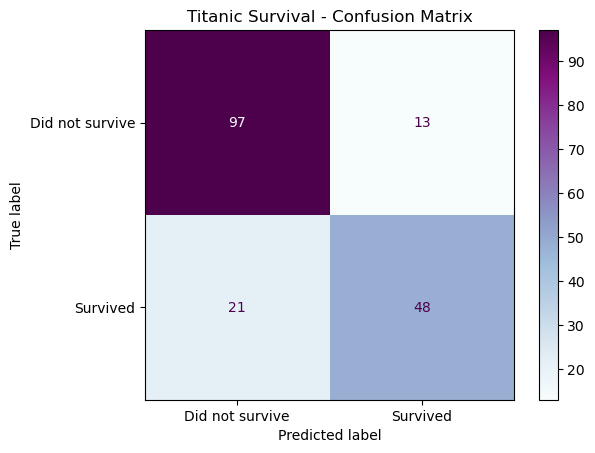

In [45]:
# 1. Separate target (y) and features (X)
y = df["Survived"]
X = df.drop("Survived", axis=1)

# 2. Convert all text/object columns (Sex, Embarked, Deck, Title) to numbers (0/1)
X = pd.get_dummies(X, drop_first=True)

# 4. Define the Base Model & Parameter Grid
base_rf = RandomForestClassifier(random_state=42)

param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [3, 5, 8, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
}

# 5. Set up GridSearchCV with 5-fold cross-validation
grid_search = GridSearchCV(
    estimator=base_rf,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
)

# 6. Fit GridSearchCV on the training data
grid_search.fit(X_train, y_train)


# 7. Print Best Hyperparameters and Score
print("--- GridSearch Results ---")
print("Best Parameters:", grid_search.best_params_)
print(f"Best 5-Fold CV Accuracy: {grid_search.best_score_:.4f}")

# 8. Evaluate on the Test Set using the best model
best_rf = grid_search.best_estimator_
predictions = best_rf.predict(X_test)

print("\n--- Test Set Classification Report ---")
print(
    classification_report(
        y_test, predictions, target_names=["Did not survive", "Survived"]
    )
)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    predictions,
    display_labels=["Did not survive", "Survived"],
    cmap="BuPu",
)
plt.title("Titanic Survival - Confusion Matrix")
plt.show()

## Step 4: Compare the tuned model's cross-validated score against the untuned baseline from Week 3

We evaluate the default model using `cross_val_score` (Untuned_RF_Model, X_train, y_train, cv=5) and compare its average accuracy against the tuned model's `grid_search.best_score_`. We calculate the mean across the 5 cross-validation folds because a single fold can be unusually easy or hard; averaging them provides a balanced, reliable estimate of how well the model generalizes to unseen data. To obtain the mean score directly, we use the `scoring="accuracy`" parameter inside both `cross_val_score()` and `GridSearchCV()`, and call the `.mean()` method on the resulting array of fold scores.

In [54]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

# 1. Untuned Baseline Model (Week 3 model with default settings)
Untuned_RF_Model = RandomForestClassifier(random_state=42)

baseline_cv_scores = cross_val_score(
    Untuned_RF_Model, X_train, y_train, cv=5, scoring="accuracy"
)
Untuned_RF_Model_mean_score = baseline_cv_scores.mean()

# 2. Tuned Model Score (From your GridSearchCV)
tuned_score = grid_search.best_score_

# 3. Print the comparison
print(f"Untuned Baseline CV Accuracy: {Untuned_RF_Model_mean_score:.4f}")
print(f"Tuned Model CV Accuracy:      {tuned_score:.4f}")
print(
    f"Improvement:                  {(tuned_score - Untuned_RF_Model_mean_score) * 100:+.2f}%"
)

Untuned Baseline CV Accuracy: 0.7937
Tuned Model CV Accuracy:      0.8343
Improvement:                  +4.07%


### Outout:
- Untuned Baseline CV Accuracy: 0.7937
- Tuned Model CV Accuracy:      0.8343
- Improvement:                  +4.07%
> By using `GridSearchCV` to explore different  hyperparameters, the model identified an better configurations that  outperformed the untuned model, increasing 5-fold cross-validation accuracy from 79.37% to 83.43% . This means that upgrading the tree parameters provided better results and generalization across the dataset.

## Step 5: Document which engineered feature and which hyperparameter mattered most

In [46]:
importance_df = pd.DataFrame(
    {"Feature": X.columns, "Importance": best_rf.feature_importances_}
).sort_values(by="Importance", ascending=False)

print("\n--- Top 10 Most Important Features ---")
print(importance_df.head(10).to_string(index=False))


--- Top 10 Most Important Features ---
     Feature  Importance
    Title_Mr    0.194454
    Sex_male    0.178780
        Fare    0.129963
         Age    0.109894
      Pclass    0.084064
Deck_Unknown    0.050921
   Title_Mrs    0.046539
       SibSp    0.044285
  Title_Miss    0.039822
       Parch    0.028496


### The feature importance results show that
`Title_Mr` was the most influential engineered feature, with a feature importance of `0.194454`. This means that the passenger's title, particularly whether they had the title "Mr", provided substantial information for predicting survival.

### The GridSearchCV where:
  ``` puthon
  {
    'max_depth': None,
    'min_samples_leaf': 2,
    'min_samples_split': 2,
    'n_estimators': 50
}
```
Among these the most notable hyperparameter is `min_samples_leaf=2`, which requires each leaf of the decision trees to contain at least two samples. This can help prevent the trees from creating overly specific rules based on individual observations, potentially improving generalization.

`max_depth=None` means the trees were allowed to grow without a predefined maximum depth, while`min_samples_split=2` is the default minimum number of samples required to split an internal node. The best number of trees was `50`.
GridSearchCV found that using 50 trees with min_samples_leaf=2 and no maximum depth produced the best cross-validated performance among the tested combinations

<hr style="height: 5px; background-color: #5A98C4 ; border: none;">

<a id="refs"></a>
# References 

- Feature Engineering : https://www.geeksforgeeks.org/machine-learning/what-is-feature-engineering/
- One-Hot Encoding : https://www.geeksforgeeks.org/machine-learning/ml-one-hot-encoding/
-  Binning : https://www.geeksforgeeks.org/machine-learning/binning-in-data-mining/
